In [ ]:
# Load necessary libraries
install.packages(c("dplyr", "tidyr"))
library(dplyr)
library(tidyr)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Runs Packages

In [ ]:
library(dplyr)
library(tidyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
# Read the data; make sure the name in the file upload matches the name in the read_csv bubble
# Do not change the skeleton
data <- read.csv("Data.csv")

# Convert relevant columns to numeric, coercing errors to NA
numeric_cols <- c(
  "Age", "RDS...accuracy",
  # Regex to find columns that end with .Estimate.Template.Number
  grep("\\.Estimate\\.Template\\.Number$", names(data), value = TRUE),
  grep("\\.Estimate\\.Template\\.Size\\.\\.cm\\.$", names(data), value = TRUE),
  grep("\\.Estimate\\.Distance\\.\\.cm\\.$", names(data), value = TRUE),
  grep("\\.Adjusted\\.Template\\.Number$", names(data), value = TRUE),
  grep("\\.Adjusted\\.Template\\.Size\\.\\.cm\\.$", names(data), value = TRUE),
  grep("\\.Adjusted\\.Distance\\.\\.cm\\.$", names(data), value = TRUE),
  grep("\\.Height\\.\\.cm\\.$", names(data), value = TRUE),
  grep("\\.Width\\.\\.cm\\.$", names(data), value = TRUE),
  grep("\\.Distance\\.\\.cm\\.$", names(data), value = TRUE),
  grep("\\.1st\\.Caliper\\.Aperture\\.\\.cm\\.$", names(data), value = TRUE),
  grep("\\.1st\\.Caliper\\.Distance\\.\\.cm\\.$", names(data), value = TRUE),
  grep("\\.2nd\\.Caliper\\.Aperture\\.\\.cm\\.$", names(data), value = TRUE),
  grep("\\.2nd\\.Caliper\\.Distance\\.\\.cm\\.$", names(data), value = TRUE)
)

# Ensure only existing columns are selected for conversion
numeric_cols <- intersect(numeric_cols, names(data))

data[numeric_cols] <- lapply(data[numeric_cols], function(x) as.numeric(as.character(x)))

print(data)

Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”


       ID     Gender Age
1       1       Male  56
2       2     Female  26
3       3       Male  21
4       4       Male  21
5       5       Male  23
6       6       Male  34
7       7     Female  21
8   30337     Female  20
9       8     Female  66
10      9       Male  24
11     10     Female  21
12     11       Male  22
13     12     Female  18
14     13     Female  24
15     14     Female  33
16     15     Female  27
17     16       Male  28
18     17       Male  31
19     18     Female  28
20     19       Male  25
21     20     Female  21
22     21       Male  34
23     22       Male  39
24     23       Male  22
25     24     Female  24
26     25     Female  19
27     26     Female  46
28     27       Male  21
29     28     Female  20
30     29     Female  22
31     30     Female  30
32     31     Female  19
33     32 Non binary  31
34     33       Male  24
35     34     Female  19
36     35     Female  22
37     36     Female  29
38     37       Male  20
39     38       Male  21


In [ ]:
# Function to calculate visual angle
calc_va_df <- function(df, size_col, dist_col) {
  if (is.character(size_col)) {
    size <- df[[size_col]]
  } else {
    size <- size_col
  }
  dist <- df[[dist_col]]
  (2 * atan(size / (2 * dist))) * (180 / pi)
}

total_lamp_height <- 358.14
planter_height <- 40

# Calculate Visual Angle of All Objects
data <- data %>%
  mutate(
    Stick1_Perceptual_VA  = calc_va_df(data, "Stick1.Estimate.Template.Size..cm.", "Stick1.Estimate.Distance..cm."),
    Stick2_Perceptual_VA  = calc_va_df(data, "Stick2.Estimate.Template.Size..cm.", "Stick2.Estimate.Distance..cm."),
    Stick3_Perceptual_VA  = calc_va_df(data, "Stick3.Estimate.Template.Size..cm.", "Stick3.Estimate.Distance..cm."),
    Stick4_Perceptual_VA  = calc_va_df(data, "Stick4.Estimate.Template.Size..cm.", "Stick4.Estimate.Distance..cm."),
    Stick7_Perceptual_VA  = calc_va_df(data, "Stick7.Estimate.Template.Size..cm.", "Stick7.Estimate.Distance..cm."),
    Stick8_Perceptual_VA  = calc_va_df(data, "Stick8.Estimate.Template.Size..cm.", "Stick8.Estimate.Distance..cm."),
    Stick9_Perceptual_VA  = calc_va_df(data, "Stick9.Estimate.Template.Size..cm.", "Stick9.Estimate.Distance..cm."),
    Stick9a_Perceptual_VA  = calc_va_df(data, "Stick9a.Estimate.Template.Size..cm.", "Stick9a.Estimate.Distance..cm."),
    Stick10_Perceptual_VA = calc_va_df(data, "Stick10.Estimate.Template.Size..cm.", "Stick10.Estimate.Distance..cm."),
    Lamp1_Perceptual_VA   = calc_va_df(data, "Lamp1.Estimate.Template.Size..cm.", "Lamp1.Estimate.Distance..cm."),
    Lamp1a_Perceptual_VA  = calc_va_df(data, "Lamp1a.Estimate.Template.Size..cm.", "Lamp1a.Estimate.Distance..cm."),
    Lamp2_Perceptual_VA   = calc_va_df(data, "Lamp2.Estimate.Template.Size..cm.", "Lamp2.Estimate.Distance..cm."),
    Lamp2a_Perceptual_VA  = calc_va_df(data, "Lamp2a.Estimate.Template.Size..cm.", "Lamp2a.Estimate.Distance..cm."),
    Lamp3_Perceptual_VA   = calc_va_df(data, "Lamp3.Estimate.Template.Size..cm.", "Lamp3.Estimate.Distance..cm."),
    Lamp3a_Perceptual_VA  = calc_va_df(data, "Lamp3a.Estimate.Template.Size..cm.", "Lamp3a.Estimate.Distance..cm."),
    Lamp4_Perceptual_VA   = calc_va_df(data, "Lamp4.Estimate.Template.Size..cm.", "Lamp4.Estimate.Distance..cm."),
    Lamp4a_Perceptual_VA  = calc_va_df(data, "Lamp4a.Estimate.Template.Size..cm.", "Lamp4a.Estimate.Distance..cm."),
    Lamp5_Perceptual_VA   = calc_va_df(data, "Lamp5.Estimate.Template.Size..cm.", "Lamp5.Estimate.Distance..cm."),
    Lamp6_Perceptual_VA   = calc_va_df(data, "Lamp6.Estimate.Template.Size..cm.", "Lamp6.Estimate.Distance..cm."),
    Lamp7_Perceptual_VA   = calc_va_df(data, "Lamp7.Estimate.Template.Size..cm.", "Lamp7.Estimate.Distance..cm."),
    BlueBall_Perceptual_VA = calc_va_df(data, "BlueBall.Estimate.Template.Size..cm.", "BlueBall.Estimate.Distance..cm."),
    MoonBall1_Perceptual_VA   = calc_va_df(data, "MoonBall1.Estimate.Template.Size..cm.", "MoonBall1.Estimate.Distance..cm."),
    MoonBall2_Perceptual_VA   = calc_va_df(data, "MoonBall2.Estimate.Template.Size..cm.", "MoonBall2.Estimate.Distance..cm."),
    MoonBall3_Perceptual_VA   = calc_va_df(data, "MoonBall3.Estimate.Template.Size..cm.", "MoonBall3.Estimate.Distance..cm."),
    MoonBall4_Perceptual_VA   = calc_va_df(data, "MoonBall4.Estimate.Template.Size..cm.", "MoonBall4.Estimate.Distance..cm."),
    Stick1_Adjusted_VA  = calc_va_df(data, "Stick1.Adjusted.Template.Size..cm.", "Stick1.Adjusted.Distance..cm."),
    Stick2_Adjusted_VA  = calc_va_df(data, "Stick2.Adjusted.Template.Size..cm.", "Stick2.Adjusted.Distance..cm."),
    Stick3_Adjusted_VA  = calc_va_df(data, "Stick3.Adjusted.Template.Size..cm.", "Stick3.Adjusted.Distance..cm."),
    Stick4_Adjusted_VA  = calc_va_df(data, "Stick4.Adjusted.Template.Size..cm.", "Stick4.Adjusted.Distance..cm."),
    Stick7_Adjusted_VA  = calc_va_df(data, "Stick7.Adjusted.Template.Size..cm.", "Stick7.Adjusted.Distance..cm."),
    Stick8_Adjusted_VA  = calc_va_df(data, "Stick8.Adjusted.Template.Size..cm.", "Stick8.Adjusted.Distance..cm."),
    Stick9_Adjusted_VA  = calc_va_df(data, "Stick9.Adjusted.Template.Size..cm.", "Stick9.Adjusted.Distance..cm."),
    Stick9a_Adjusted_VA  = calc_va_df(data, "Stick9a.Adjusted.Template.Size..cm.", "Stick9a.Adjusted.Distance..cm."),
    Stick10_Adjusted_VA = calc_va_df(data, "Stick10.Adjusted.Template.Size..cm.", "Stick10.Adjusted.Distance..cm."),
    Lamp1_Adjusted_VA   = calc_va_df(data, "Lamp1.Adjusted.Template.Size..cm.", "Lamp1.Adjusted.Distance..cm."),
    Lamp1a_Adjusted_VA  = calc_va_df(data, "Lamp1a.Adjusted.Template.Size..cm.", "Lamp1a.Adjusted.Distance..cm."),
    Lamp2_Adjusted_VA   = calc_va_df(data, "Lamp2.Adjusted.Template.Size..cm.", "Lamp2.Adjusted.Distance..cm."),
    Lamp2a_Adjusted_VA  = calc_va_df(data, "Lamp2a.Adjusted.Template.Size..cm.", "Lamp2a.Adjusted.Distance..cm."),
    Lamp3_Adjusted_VA   = calc_va_df(data, "Lamp3.Adjusted.Template.Size..cm.", "Lamp3.Adjusted.Distance..cm."),
    Lamp3a_Adjusted_VA  = calc_va_df(data, "Lamp3a.Adjusted.Template.Size..cm.", "Lamp3a.Adjusted.Distance..cm."),
    Lamp4_Adjusted_VA   = calc_va_df(data, "Lamp4.Adjusted.Template.Size..cm.", "Lamp4.Adjusted.Distance..cm."),
    Lamp4a_Adjusted_VA  = calc_va_df(data, "Lamp4a.Adjusted.Template.Size..cm.", "Lamp4a.Adjusted.Distance..cm."),
    Lamp5_Adjusted_VA   = calc_va_df(data, "Lamp5.Adjusted.Template.Size..cm.", "Lamp5.Adjusted.Distance..cm."),
    Lamp6_Adjusted_VA   = calc_va_df(data, "Lamp6.Adjusted.Template.Size..cm.", "Lamp6.Adjusted.Distance..cm."),
    Lamp7_Adjusted_VA   = calc_va_df(data, "Lamp7.Adjusted.Template.Size..cm.", "Lamp7.Adjusted.Distance..cm."),
    BlueBall_Adjusted_VA = calc_va_df(data, "BlueBall.Adjusted.Template.Size..cm.", "BlueBall.Adjusted.Distance..cm."),
    MoonBall1_Adjusted_VA   = calc_va_df(data, "MoonBall1.Adjusted.Template.Size..cm.", "MoonBall1.Adjusted.Distance..cm."),
    MoonBall2_Adjusted_VA   = calc_va_df(data, "MoonBall2.Adjusted.Template.Size..cm.", "MoonBall2.Adjusted.Distance..cm."),
    MoonBall3_Adjusted_VA   = calc_va_df(data, "MoonBall3.Adjusted.Template.Size..cm.", "MoonBall3.Adjusted.Distance..cm."),
    MoonBall4_Adjusted_VA   = calc_va_df(data, "MoonBall4.Adjusted.Template.Size..cm.", "MoonBall4.Adjusted.Distance..cm."),
# Real Visual Angle Calculation
    Stick10_Real_Visual_Angle = calc_va_df(data, "Stick10.Height..cm.", "Stick10.Distance..cm."),
    Stick1_Real_Visual_Angle  = calc_va_df(data, "Stick1.Height..cm.", "Stick1.Distance..cm."),
    Stick2_Real_Visual_Angle  = calc_va_df(data, "Stick2.Height..cm.", "Stick2.Distance..cm."),
    Stick3_Real_Visual_Angle  = calc_va_df(data, "Stick3.Height..cm.", "Stick3.Distance..cm."),
    Stick4_Real_Visual_Angle  = calc_va_df(data, "Stick4.Height..cm.", "Stick4.Distance..cm."),
    Stick7_Real_Visual_Angle  = calc_va_df(data, "Stick7.Height..cm.", "Stick7.Distance..cm."),
    Stick8_Real_Visual_Angle  = calc_va_df(data, "Stick8.Height..cm.", "Stick8.Distance..cm."),
    Stick9_Real_Visual_Angle  = calc_va_df(data, "Stick9.Height..cm.", "Stick9.Distance..cm."),
    Stick9a_Real_Visual_Angle = calc_va_df(data, "Stick9a.Height..cm.", "Stick9a.Distance..cm."),
    Lamp1a_Real_Visual_Angle  = calc_va_df(data, "Lamp1a.Width..cm.", "Lamp1a.Distance..cm."),
    Lamp2a_Real_Visual_Angle  = calc_va_df(data, "Lamp2a.Width..cm.", "Lamp2a.Distance..cm."),
    Lamp3a_Real_Visual_Angle  = calc_va_df(data, "Lamp3a.Width..cm.", "Lamp3a.Distance..cm."),
    Lamp4a_Real_Visual_Angle  = calc_va_df(data, "Lamp4a.Width..cm.", "Lamp4a.Distance..cm."),
    Lamp5_Real_Visual_Angle   = calc_va_df(data, "Lamp5.Width..cm.", "Lamp5.Distance..cm."),
    Lamp6_Real_Visual_Angle   = calc_va_df(data, "Lamp6.Width..cm.", "Lamp6.Distance..cm."),
    Lamp7_Real_Visual_Angle   = calc_va_df(data, "Lamp7.Width..cm.", "Lamp7.Distance..cm."),
    BlueBall_Real_Visual_Angle  = calc_va_df(data, "BlueBall.Width..cm.", "BlueBall.Distance..cm."),
    MoonBall1_Real_Visual_Angle = calc_va_df(data, "MoonBall1.Width..cm.", "MoonBall1.Distance..cm."),
    MoonBall2_Real_Visual_Angle = calc_va_df(data, "MoonBall2.Width..cm.", "MoonBall2.Distance..cm."),
    MoonBall3_Real_Visual_Angle = calc_va_df(data, "MoonBall3.Width..cm.", "MoonBall3.Distance..cm."),
    MoonBall4_Real_Visual_Angle = calc_va_df(data, "MoonBall4.Width..cm.", "MoonBall4.Distance..cm."),
    Lamp1_Real_Visual_Angle     = calc_va_df(data, "Lamp1.Width..cm.", "Lamp1.Distance..cm."),
    Lamp2_Real_Visual_Angle     = calc_va_df(data, "Lamp2.Width..cm.", "Lamp2.Distance..cm."),
    Lamp3_Real_Visual_Angle     = calc_va_df(data, "Lamp3.Width..cm.", "Lamp3.Distance..cm."),
    Lamp4_Real_Visual_Angle     = calc_va_df(data, "Lamp4.Width..cm.", "Lamp4.Distance..cm."),

#Elevation Calculations
    Stick10_Elevation = atan(((total_lamp_height / 2)  + 20.9) / data$Stick10.Distance..cm.) * (180 / pi),
    Stick1_Elevation = atan(((total_lamp_height / 2)  + 20.9) / data$Stick1.Distance..cm.) * (180 / pi),
    Stick2_Elevation = atan(((total_lamp_height / 2)  + 20.9) / data$Stick2.Distance..cm.) * (180 / pi),
    Stick3_Elevation = atan(((total_lamp_height / 2)  + 20.9) / data$Stick3.Distance..cm.) * (180 / pi),
    Stick4_Elevation = atan(((total_lamp_height / 2)  + 20.9) / data$Stick4.Distance..cm.) * (180 / pi),
    Stick7_Elevation = atan(((total_lamp_height / 2)  + 20.9) / data$Stick7.Distance..cm.) * (180 / pi),
    Stick8_Elevation = atan(((total_lamp_height / 2)  + 20.9) / data$Stick8.Distance..cm.) * (180 / pi),
    Stick9_Elevation = atan(((total_lamp_height / 2 ) + 20.9) / data$Stick9.Distance..cm.) * (180 / pi),
    Stick9a_Elevation = atan(((total_lamp_height / 2) + 20.9) / data$Stick9a.Distance..cm.) * (180 / pi),
    Lamp1_Elevation = atan((total_lamp_height + 20.32 + 20.9) / data$Lamp1.Distance..cm.) * (180 / pi),
    Lamp2_Elevation = atan((total_lamp_height + 20.32 + 20.9) / data$Lamp2.Distance..cm.) * (180 / pi),
    Lamp3_Elevation = atan((total_lamp_height + 20.32 + 20.9) / data$Lamp3.Distance..cm.) * (180 / pi),
    Lamp4_Elevation = atan((total_lamp_height + 20.32 + 20.9) / data$Lamp4.Distance..cm.) * (180 / pi),
    Lamp5_Elevation = atan((total_lamp_height + 20.32 + 20.9) / data$Lamp5.Distance..cm.) * (180 / pi),
    Lamp6_Elevation = atan((total_lamp_height + 20.32 + 20.9) / data$Lamp6.Distance..cm.) * (180 / pi),
    Lamp7_Elevation     = atan((total_lamp_height + 20.32 + 20.9) / data$Lamp7.Distance..cm.) * (180 / pi),
    Lamp1a_Elevation = atan((total_lamp_height + 20.32 + 20.9) / data$Lamp1a.Distance..cm.) * (180 / pi),
    Lamp2a_Elevation = atan((total_lamp_height + 20.32 + 20.9) / data$Lamp2a.Distance..cm.) * (180 / pi),
    Lamp3a_Elevation = atan((total_lamp_height + 20.32 + 20.9) / data$Lamp3a.Distance..cm.) * (180 / pi),
    Lamp4a_Elevation = atan((total_lamp_height + 20.32 + 20.9) / data$Lamp4a.Distance..cm.) * (180 / pi),
    MoonBall1_Elevation = atan((planter_height + 27.5) / data$MoonBall1.Distance..cm.) * (180 / pi),
    MoonBall2_Elevation = atan((planter_height + 27.5) / data$MoonBall2.Distance..cm.) * (180 / pi),
    MoonBall3_Elevation = atan((planter_height + 27.5) / data$MoonBall3.Distance..cm.) * (180 / pi),
    MoonBall4_Elevation = atan((planter_height + 27.5) / data$MoonBall4.Distance..cm.) * (180 / pi),
    BlueBall_Elevation = atan((planter_height + 13.37) / data$BlueBall.Distance..cm.) * (180 / pi)
  )


print(data)

       ID     Gender Age
1       1       Male  56
2       2     Female  26
3       3       Male  21
4       4       Male  21
5       5       Male  23
6       6       Male  34
7       7     Female  21
8   30337     Female  20
9       8     Female  66
10      9       Male  24
11     10     Female  21
12     11       Male  22
13     12     Female  18
14     13     Female  24
15     14     Female  33
16     15     Female  27
17     16       Male  28
18     17       Male  31
19     18     Female  28
20     19       Male  25
21     20     Female  21
22     21       Male  34
23     22       Male  39
24     23       Male  22
25     24     Female  24
26     25     Female  19
27     26     Female  46
28     27       Male  21
29     28     Female  20
30     29     Female  22
31     30     Female  30
32     31     Female  19
33     32 Non binary  31
34     33       Male  24
35     34     Female  19
36     35     Female  22
37     36     Female  29
38     37       Male  20
39     38       Male  21


In [ ]:
data_long <- data %>%
  select(ID = 1, Gender, Date, Time, Age, Version,
        Stick1_Perceptual_VA, Stick1_Adjusted_VA,
        Stick2_Perceptual_VA, Stick2_Adjusted_VA,
        Stick3_Perceptual_VA, Stick3_Adjusted_VA,
        Stick4_Perceptual_VA, Stick4_Adjusted_VA,
        Stick7_Perceptual_VA, Stick7_Adjusted_VA,
        Stick8_Perceptual_VA, Stick8_Adjusted_VA,
        Stick9_Perceptual_VA, Stick9_Adjusted_VA,
        Stick9a_Perceptual_VA, Stick9a_Adjusted_VA,
        Stick10_Perceptual_VA, Stick10_Adjusted_VA,
        Lamp1_Perceptual_VA, Lamp1_Adjusted_VA,
        Lamp2_Perceptual_VA, Lamp2_Adjusted_VA,
        Lamp3_Perceptual_VA, Lamp3_Adjusted_VA,
        Lamp4_Perceptual_VA, Lamp4_Adjusted_VA,
        Lamp1a_Perceptual_VA, Lamp1a_Adjusted_VA,
        Lamp2a_Perceptual_VA, Lamp2a_Adjusted_VA,
        Lamp3a_Perceptual_VA, Lamp3a_Adjusted_VA,
        Lamp4a_Perceptual_VA, Lamp4a_Adjusted_VA,
        Lamp5_Perceptual_VA, Lamp5_Adjusted_VA,
        Lamp6_Perceptual_VA, Lamp6_Adjusted_VA,
        Lamp7_Perceptual_VA, Lamp7_Adjusted_VA,
        BlueBall_Perceptual_VA, BlueBall_Adjusted_VA,
        MoonBall1_Perceptual_VA, MoonBall1_Adjusted_VA,
        MoonBall2_Perceptual_VA, MoonBall2_Adjusted_VA,
        MoonBall3_Perceptual_VA, MoonBall3_Adjusted_VA,
        MoonBall4_Perceptual_VA, MoonBall4_Adjusted_VA

  ) %>%
  pivot_longer(
    cols = -c(ID, Gender, Age, Date, Time, Version),
    names_to = "Measurement",
    values_to = "Reported_Visual_Angle") %>%
  filter(!is.na(Reported_Visual_Angle)) %>%
  mutate(
    Real_Visual_Angle = case_when(
      grepl("Lamp1a",   Measurement) ~ data$Lamp1a_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Lamp2a",   Measurement) ~ data$Lamp2a_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Lamp3a",   Measurement) ~ data$Lamp3a_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Lamp4a",   Measurement) ~ data$Lamp4a_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Lamp5",    Measurement) ~ data$Lamp5_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Lamp6",    Measurement) ~ data$Lamp6_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Lamp7",    Measurement) ~ data$Lamp7_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Lamp1",    Measurement) ~ data$Lamp1_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Lamp2",    Measurement) ~ data$Lamp2_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Lamp3",    Measurement) ~ data$Lamp3_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Lamp4",    Measurement) ~ data$Lamp4_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Stick10",  Measurement) ~ data$Stick10_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Stick1",   Measurement) ~ data$Stick1_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Stick2",   Measurement) ~ data$Stick2_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Stick3",  Measurement) ~ data$Stick3_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Stick4",   Measurement) ~ data$Stick4_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Stick7",   Measurement) ~ data$Stick7_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Stick8",   Measurement) ~ data$Stick8_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Stick9a",  Measurement) ~ data$Stick9a_Real_Visual_Angle[match(ID, data$ID)],
      grepl("Stick9",   Measurement) ~ data$Stick9_Real_Visual_Angle[match(ID, data$ID)],
      grepl("BlueBall", Measurement) ~ data$BlueBall_Real_Visual_Angle[match(ID, data$ID)],
      grepl("MoonBall1",Measurement) ~ data$MoonBall1_Real_Visual_Angle[match(ID, data$ID)],
      grepl("MoonBall2",Measurement) ~ data$MoonBall2_Real_Visual_Angle[match(ID, data$ID)],
      grepl("MoonBall3",Measurement) ~ data$MoonBall3_Real_Visual_Angle[match(ID, data$ID)],
      grepl("MoonBall4",Measurement) ~ data$MoonBall4_Real_Visual_Angle[match(ID, data$ID)],
      TRUE ~ NA_real_
    ),


    Task = case_when(
      grepl("Perceptual", Measurement) ~ "Perceptual",
      grepl("Adjusted", Measurement) ~ "Adjusted"
    ),

    Ratio_Visual_Angle = Reported_Visual_Angle / Real_Visual_Angle
    ,

     Distance = case_when(
      grepl("Lamp1a", Measurement) ~ data$Lamp1a.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp2a", Measurement) ~ data$Lamp2a.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp3a", Measurement) ~ data$Lamp3a.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp4a", Measurement) ~ data$Lamp4a.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp1", Measurement) ~ data$Lamp1.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp2", Measurement) ~ data$Lamp2.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp3", Measurement) ~ data$Lamp3.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp4", Measurement) ~ data$Lamp4.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp5", Measurement) ~ data$Lamp5.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp6", Measurement) ~ data$Lamp6.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp7", Measurement) ~ data$Lamp7.Distance..cm.[match(ID, data$ID)],
      grepl("Stick10", Measurement) ~ data$Stick10.Distance..cm.[match(ID, data$ID)],
      grepl("Stick1", Measurement) ~ data$Stick1.Distance..cm.[match(ID, data$ID)],
      grepl("Stick2", Measurement) ~ data$Stick2.Distance..cm.[match(ID, data$ID)],
      grepl("Stick3", Measurement) ~ data$Stick3.Distance..cm.[match(ID, data$ID)],
      grepl("Stick4", Measurement) ~ data$Stick4.Distance..cm.[match(ID, data$ID)],
      grepl("Stick7", Measurement) ~ data$Stick7.Distance..cm.[match(ID, data$ID)],
      grepl("Stick8", Measurement) ~ data$Stick8.Distance..cm.[match(ID, data$ID)],
      grepl("Stick9a", Measurement) ~ data$Stick9a.Distance..cm.[match(ID, data$ID)],
      grepl("Stick9", Measurement) ~ data$Stick9.Distance..cm.[match(ID, data$ID)],
      grepl("BlueBall", Measurement) ~ data$BlueBall.Distance..cm.[match(ID, data$ID)],
      grepl("MoonBall1", Measurement) ~ data$MoonBall1.Distance..cm.[match(ID, data$ID)],
      grepl("MoonBall2", Measurement) ~ data$MoonBall2.Distance..cm.[match(ID, data$ID)],
      grepl("MoonBall3", Measurement) ~ data$MoonBall3.Distance..cm.[match(ID, data$ID)],
      grepl("MoonBall4", Measurement) ~ data$MoonBall4.Distance..cm.[match(ID, data$ID)],
      TRUE ~ NA_real_
    ),

    Width = case_when(
      grepl("Lamp1a", Measurement) ~ data$Lamp1a.Width..cm.[match(ID, data$ID)],
      grepl("Lamp2a", Measurement) ~ data$Lamp2a.Width..cm.[match(ID, data$ID)],
      grepl("Lamp3a", Measurement) ~ data$Lamp3a.Width..cm.[match(ID, data$ID)],
      grepl("Lamp4a", Measurement) ~ data$Lamp4a.Width..cm.[match(ID, data$ID)],
      grepl("Lamp1", Measurement) ~ data$Lamp1.Width..cm.[match(ID, data$ID)],
      grepl("Lamp2", Measurement) ~ data$Lamp2.Width..cm.[match(ID, data$ID)],
      grepl("Lamp3", Measurement) ~ data$Lamp3.Width..cm.[match(ID, data$ID)],
      grepl("Lamp4", Measurement) ~ data$Lamp4.Width..cm.[match(ID, data$ID)],
      grepl("Lamp5", Measurement) ~ data$Lamp5.Width..cm.[match(ID, data$ID)],
      grepl("Lamp6", Measurement) ~ data$Lamp6.Width..cm.[match(ID, data$ID)],
      grepl("Lamp7", Measurement) ~ data$Lamp7.Width..cm.[match(ID, data$ID)],
      grepl("Stick1", Measurement) ~ data$Stick1.Width..cm.[match(ID, data$ID)],
      grepl("Stick2", Measurement) ~ data$Stick2.Width..cm.[match(ID, data$ID)],
      grepl("Stick3", Measurement) ~ data$Stick3.Width..cm.[match(ID, data$ID)],
      grepl("Stick4", Measurement) ~ data$Stick4.Width..cm.[match(ID, data$ID)],
      grepl("Stick7", Measurement) ~ data$Stick7.Width..cm.[match(ID, data$ID)],
      grepl("Stick8", Measurement) ~ data$Stick8.Width..cm.[match(ID, data$ID)],
      grepl("Stick9a", Measurement) ~ data$Stick9a.Width..cm.[match(ID, data$ID)],
      grepl("Stick9", Measurement) ~ data$Stick9.Width..cm.[match(ID, data$ID)],
      grepl("Stick10", Measurement) ~ data$Stick10.Width..cm.[match(ID, data$ID)],
      grepl("BlueBall", Measurement) ~ data$BlueBall.Width..cm.[match(ID, data$ID)],
      grepl("MoonBall1", Measurement) ~ data$MoonBall1.Width..cm.[match(ID, data$ID)],
      grepl("MoonBall2", Measurement) ~ data$MoonBall2.Width..cm.[match(ID, data$ID)],
      grepl("MoonBall3", Measurement) ~ data$MoonBall3.Width..cm.[match(ID, data$ID)],
      grepl("MoonBall4", Measurement) ~ data$MoonBall4.Width..cm.[match(ID, data$ID)],
      TRUE ~ NA_real_
    ),

    Elevation = case_when(
      grepl("Lamp1a", Measurement) ~ data$Lamp1a_Elevation[match(ID, data$ID)],
      grepl("Lamp2a", Measurement) ~ data$Lamp2a_Elevation[match(ID, data$ID)],
      grepl("Lamp3a", Measurement) ~ data$Lamp3a_Elevation[match(ID, data$ID)],
      grepl("Lamp4a", Measurement) ~ data$Lamp4a_Elevation[match(ID, data$ID)],
      grepl("Lamp1", Measurement) ~ data$Lamp1_Elevation[match(ID, data$ID)],
      grepl("Lamp2", Measurement) ~ data$Lamp2_Elevation[match(ID, data$ID)],
      grepl("Lamp3", Measurement) ~ data$Lamp3_Elevation[match(ID, data$ID)],
      grepl("Lamp4", Measurement) ~ data$Lamp4_Elevation[match(ID, data$ID)],
      grepl("Lamp5", Measurement) ~ data$Lamp5_Elevation[match(ID, data$ID)],
      grepl("Lamp6", Measurement) ~ data$Lamp6_Elevation[match(ID, data$ID)],
      grepl("Lamp7", Measurement) ~ data$Lamp7_Elevation[match(ID, data$ID)],
      grepl("Stick10", Measurement) ~ data$Stick10_Elevation[match(ID, data$ID)],
      grepl("Stick1", Measurement) ~ data$Stick1_Elevation[match(ID, data$ID)],
      grepl("Stick2", Measurement) ~ data$Stick2_Elevation[match(ID, data$ID)],
      grepl("Stick3", Measurement) ~ data$Stick3_Elevation[match(ID, data$ID)],
      grepl("Stick4", Measurement) ~ data$Stick4_Elevation[match(ID, data$ID)],
      grepl("Stick7", Measurement) ~ data$Stick7_Elevation[match(ID, data$ID)],
      grepl("Stick8", Measurement) ~ data$Stick8_Elevation[match(ID, data$ID)],
      grepl("Stick9a", Measurement) ~ data$Stick9a_Elevation[match(ID, data$ID)],
      grepl("Stick9", Measurement) ~ data$Stick9_Elevation[match(ID, data$ID)],
      grepl("MoonBall1", Measurement) ~ data$MoonBall1_Elevation[match(ID, data$ID)],
      grepl("MoonBall2", Measurement) ~ data$MoonBall2_Elevation[match(ID, data$ID)],
      grepl("MoonBall3", Measurement) ~ data$MoonBall3_Elevation[match(ID, data$ID)],
      grepl("MoonBall4", Measurement) ~ data$MoonBall4_Elevation[match(ID, data$ID)],
      grepl("BlueBall", Measurement) ~ data$BlueBall_Elevation[match(ID, data$ID)]
    ),
    Template_Size = case_when(
     grepl("Lamp1a", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp1a.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp1a", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp1a.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp2a", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp2a.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp2a", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp2a.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp3a", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp3a.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp3a", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp3a.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp4a", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp4a.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp4a", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp4a.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp1", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp1.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp1", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp1.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp2", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp2.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp2", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp2.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp3", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp3.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp3", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp3.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp4", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp4.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp4", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp4.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp5", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp5.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp5", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp5.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp6", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp6.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp6", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp6.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp7", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp7.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Lamp7", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp7.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick10", Measurement)  & grepl("Perceptual", Task) ~ data$Stick10.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick10", Measurement)  & grepl("Adjusted", Task) ~ data$Stick10.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick1", Measurement)  & grepl("Perceptual", Task) ~ data$Stick1.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick1", Measurement)  & grepl("Adjusted", Task) ~ data$Stick1.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick2", Measurement)  & grepl("Perceptual", Task) ~ data$Stick2.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick2", Measurement)  & grepl("Adjusted", Task) ~ data$Stick2.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick3", Measurement)  & grepl("Perceptual", Task) ~ data$Stick3.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick3", Measurement)  & grepl("Adjusted", Task) ~ data$Stick3.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick4", Measurement)  & grepl("Perceptual", Task) ~ data$Stick4.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick4", Measurement)  & grepl("Adjusted", Task) ~ data$Stick4.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick7", Measurement)  & grepl("Perceptual", Task) ~ data$Stick7.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick7", Measurement)  & grepl("Adjusted", Task) ~ data$Stick7.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick8", Measurement)  & grepl("Perceptual", Task) ~ data$Stick8.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick8", Measurement)  & grepl("Adjusted", Task) ~ data$Stick8.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick9a", Measurement)  & grepl("Perceptual", Task) ~ data$Stick9a.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick9a", Measurement)  & grepl("Adjusted", Task) ~ data$Stick9a.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick9", Measurement)  & grepl("Perceptual", Task) ~ data$Stick9.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("Stick9", Measurement)  & grepl("Adjusted", Task) ~ data$Stick9.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("MoonBall1", Measurement)  & grepl("Perceptual", Task) ~ data$MoonBall1.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("MoonBall1", Measurement)  & grepl("Adjusted", Task) ~ data$MoonBall1.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("MoonBall2", Measurement)  & grepl("Perceptual", Task) ~ data$MoonBall2.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("MoonBall2", Measurement)  & grepl("Adjusted", Task) ~ data$MoonBall2.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("MoonBall3", Measurement)  & grepl("Perceptual", Task) ~ data$MoonBall3.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("MoonBall3", Measurement)  & grepl("Adjusted", Task) ~ data$MoonBall3.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("MoonBall4", Measurement)  & grepl("Perceptual", Task) ~ data$MoonBall4.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("MoonBall4", Measurement)  & grepl("Adjusted", Task) ~ data$MoonBall4.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      grepl("BlueBall", Measurement)  & grepl("Perceptual", Task) ~ data$BlueBall.Estimate.Template.Size..cm.[match(ID, data$ID)],
      grepl("BlueBall", Measurement)  & grepl("Adjusted", Task) ~ data$BlueBall.Adjusted.Template.Size..cm.[match(ID, data$ID)],
      TRUE ~ NA_real_
    ),
    Arm_Length = case_when(
      grepl("Lamp1a", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp1a.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp1a", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp1a.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp2a", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp2a.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp2a", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp2a.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp3a", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp3a.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp3a", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp3a.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp4a", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp4a.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp4a", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp4a.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp1", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp1.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp1", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp1.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp2", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp2.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp2", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp2.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp3", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp3.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp3", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp3.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp4", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp4.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp4", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp4.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp5", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp5.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp5", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp5.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp6", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp6.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp6", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp6.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp7", Measurement)  & grepl("Perceptual", Task) ~ data$Lamp7.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Lamp7", Measurement)  & grepl("Adjusted", Task) ~ data$Lamp7.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Stick10", Measurement)  & grepl("Perceptual", Task) ~ data$Stick10.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Stick10", Measurement)  & grepl("Adjusted", Task) ~ data$Stick10.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Stick1", Measurement)  & grepl("Perceptual", Task) ~ data$Stick1.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Stick1", Measurement)  & grepl("Adjusted", Task) ~ data$Stick1.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Stick2", Measurement)  & grepl("Perceptual", Task) ~ data$Stick2.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Stick2", Measurement)  & grepl("Adjusted", Task) ~ data$Stick2.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Stick3", Measurement)  & grepl("Perceptual", Task) ~ data$Stick3.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Stick3", Measurement)  & grepl("Adjusted", Task) ~ data$Stick3.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Stick4", Measurement)  & grepl("Perceptual", Task) ~ data$Stick4.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Stick4", Measurement)  & grepl("Adjusted", Task) ~ data$Stick4.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Stick7", Measurement)  & grepl("Perceptual", Task) ~ data$Stick7.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Stick7", Measurement)  & grepl("Adjusted", Task) ~ data$Stick7.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Stick8", Measurement)  & grepl("Perceptual", Task) ~ data$Stick8.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Stick8", Measurement)  & grepl("Adjusted", Task) ~ data$Stick8.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Stick9a", Measurement)  & grepl("Perceptual", Task) ~ data$Stick9a.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Stick9a", Measurement)  & grepl("Adjusted", Task) ~ data$Stick9a.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("Stick9", Measurement)  & grepl("Perceptual", Task) ~ data$Stick9.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("Stick9", Measurement)  & grepl("Adjusted", Task) ~ data$Stick9.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("MoonBall1", Measurement)  & grepl("Perceptual", Task) ~ data$MoonBall1.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("MoonBall1", Measurement)  & grepl("Adjusted", Task) ~ data$MoonBall1.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("MoonBall2", Measurement)  & grepl("Perceptual", Task) ~ data$MoonBall2.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("MoonBall2", Measurement)  & grepl("Adjusted", Task) ~ data$MoonBall2.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("MoonBall3", Measurement)  & grepl("Perceptual", Task) ~ data$MoonBall3.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("MoonBall3", Measurement)  & grepl("Adjusted", Task) ~ data$MoonBall3.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("MoonBall4", Measurement)  & grepl("Perceptual", Task) ~ data$MoonBall4.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("MoonBall4", Measurement)  & grepl("Adjusted", Task) ~ data$MoonBall4.Adjusted.Distance..cm.[match(ID, data$ID)],
      grepl("BlueBall", Measurement)  & grepl("Perceptual", Task) ~ data$BlueBall.Estimate.Distance..cm.[match(ID, data$ID)],
      grepl("BlueBall", Measurement)  & grepl("Adjusted", Task) ~ data$BlueBall.Adjusted.Distance..cm.[match(ID, data$ID)],
      TRUE ~ NA_real_
    ),
  )

write.csv(data_long, file = "AllQuadDataLong.csv")

In [ ]:
library(ggplot2)

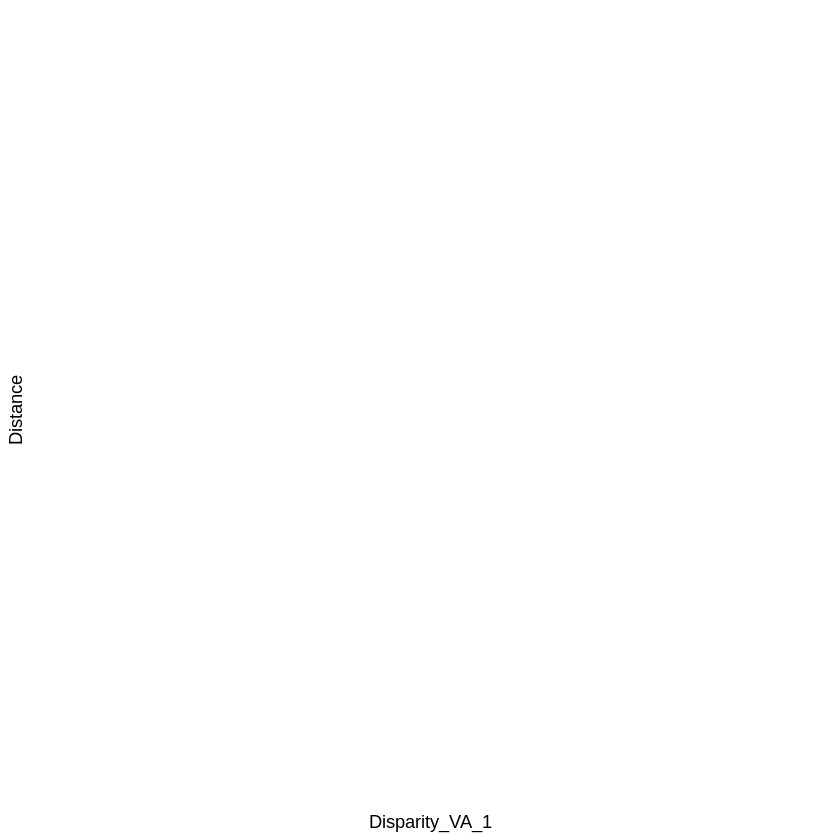

In [ ]:
ggplot(data = data_long, aes(x = Disparity_VA_1, y = Distance)) +
  geom_point(alpha = .6) +
  # labs(title = "Do people perceive visual angle accurately?",
  #      x = "Real Visual Angle(deg)",
  #      y = "Reported Visual Angle(deg)") +
  theme_classic()